# 04 — Encoder Selection Experiment

**Goal:** Select the best text representation and embedding model for Bulgarian news event clustering.


In [57]:
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import umap
import hdbscan

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

## 1. Load data — last 7 days

In [31]:
df = pd.read_parquet("../data/processed/articles_clean.parquet")

cutoff = df["published_at_dt"].max() - pd.Timedelta(days=3)
exp_df = df[df["published_at_dt"] >= cutoff].copy().reset_index(drop=True)

print(f"Total articles : {len(exp_df)}")
print(f"Date range     : {exp_df['published_at_dt'].min().date()} → {exp_df['published_at_dt'].max().date()}")
print("\nPer source:")
print(exp_df["source"].value_counts().to_string())

Total articles : 3735
Date range     : 2026-05-18 → 2026-05-21

Per source:
source
24chasa         907
actualno        559
fakti           423
bta             349
monitor         329
standartnews    329
vesti           286
nova            275
segabg          130
banker          101
economic         47


In [32]:
exp_df.groupby([exp_df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-05-18,262,162,33,94,15,124,88,89,34,108,85
2026-05-19,323,191,38,119,16,149,94,91,46,121,94
2026-05-20,312,196,30,119,16,128,120,89,48,97,102
2026-05-21,10,10,0,17,0,22,27,6,2,3,5


## 2. Text combination experiment

Fixed model: **BAAI/bge-m3** (strong multilingual baseline, 8192 token context).

Combinations tested:
- `title` only
- `lead` only (first 3 sentences of full_text)
- `title + lead` ← hypothesis: best balance of signal and noise
- `full_text` (truncated to model limit)

**Evaluation:** pairwise cosine similarity gap (same-source vs cross-source) + UMAP visualization.
A smaller gap indicates less source-style bias — the model captures topic rather than writing style.


In [33]:
def extract_lead(text: str, n_sentences: int = 3) -> str:
    if not isinstance(text, str):
        return ""
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return " ".join(sentences[:n_sentences])

exp_df["lead"] = exp_df["full_text"].apply(extract_lead)

TEXT_VARIANTS = {
    "full_text": exp_df["full_text"].fillna("").tolist(),
    "title": exp_df["title"].tolist(),
    "lead": exp_df["lead"].tolist(),
    "title+lead": (exp_df["title"] + ". " + exp_df["lead"]).tolist(),
}

print("Text variants prepared:")
for k, v in TEXT_VARIANTS.items():
    sample_len = sum(len(t.split()) for t in v) / len(v)
    print(f"  {k:<15}: avg {sample_len:.0f} words")

Text variants prepared:
  full_text      : avg 335 words
  title          : avg 11 words
  lead           : avg 66 words
  title+lead     : avg 77 words


In [34]:
DEVICE = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device: {DEVICE}")

TEXT_MODEL_ID = "BAAI/bge-m3"
text_model = SentenceTransformer(TEXT_MODEL_ID, device=DEVICE)
print("Model loaded.")

Device: mps


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded.


In [35]:
text_embeddings = {}

for variant_name, texts in TEXT_VARIANTS.items():
    print(f"\nEmbedding: {variant_name}")
    text_embeddings[variant_name] = text_model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=1,
    )
    print(f"Shape: {text_embeddings[variant_name].shape}")


Embedding: full_text


Batches:   0%|          | 0/3735 [00:00<?, ?it/s]

Shape: (3735, 1024)

Embedding: title


Batches:   0%|          | 0/3735 [00:00<?, ?it/s]

Shape: (3735, 1024)

Embedding: lead


Batches:   0%|          | 0/3735 [00:00<?, ?it/s]

Shape: (3735, 1024)

Embedding: title+lead


Batches:   0%|          | 0/3735 [00:00<?, ?it/s]

Shape: (3735, 1024)


In [39]:
def similarity_stats(emb, name, df):
    sim = cosine_similarity(emb)

    sources = df["source"].to_numpy()
    same_mask = sources[:, None] == sources[None, :]
    upper = np.triu(np.ones(len(sim), dtype=bool), k=1)

    same = sim[upper & same_mask]
    cross = sim[upper & ~same_mask]

    return {
        "variant": name,
        "same_source_mean": round(float(np.mean(same)), 3),
        "cross_source_mean": round(float(np.mean(cross)), 3),
        "gap": round(float(np.mean(same) - np.mean(cross)), 3),
    }

In [40]:
text_sim_results = [similarity_stats(emb, name, exp_df) for name, emb in text_embeddings.items()]
text_sim_df = pd.DataFrame(text_sim_results).sort_values("gap")
print(text_sim_df.to_string(index=False))

   variant  same_source_mean  cross_source_mean   gap
 full_text             0.327              0.323 0.003
      lead             0.311              0.308 0.003
title+lead             0.311              0.308 0.003
     title             0.285              0.280 0.005


### Results — Text combination similarity statistics

**Metric:** Pairwise cosine similarity gap between same-source and cross-source article pairs.
A smaller gap indicates less source-style bias — the embedding captures topic rather than writing style.
This is critical for event clustering: we want articles about the same event from different sources
to be closer together than articles from the same source about different topics.

**Observations:**
- `lead`, `title+lead` and `full_text` are tied at gap 0.003 — the three best options
- `title` alone is the worst with gap 0.005 — the model captures source writing style more than topic when given only the title
- `lead` and `title+lead` produce identical results — the title adds no additional signal to the gap metric with BGE-M3
- `full_text` has a slightly higher overall similarity range (0.327 vs 0.311) — marginally more compressed embedding space
- The similarity stats alone cannot distinguish between `lead`, `title+lead` and `full_text` — the UMAP visualization is needed as a tiebreaker


/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


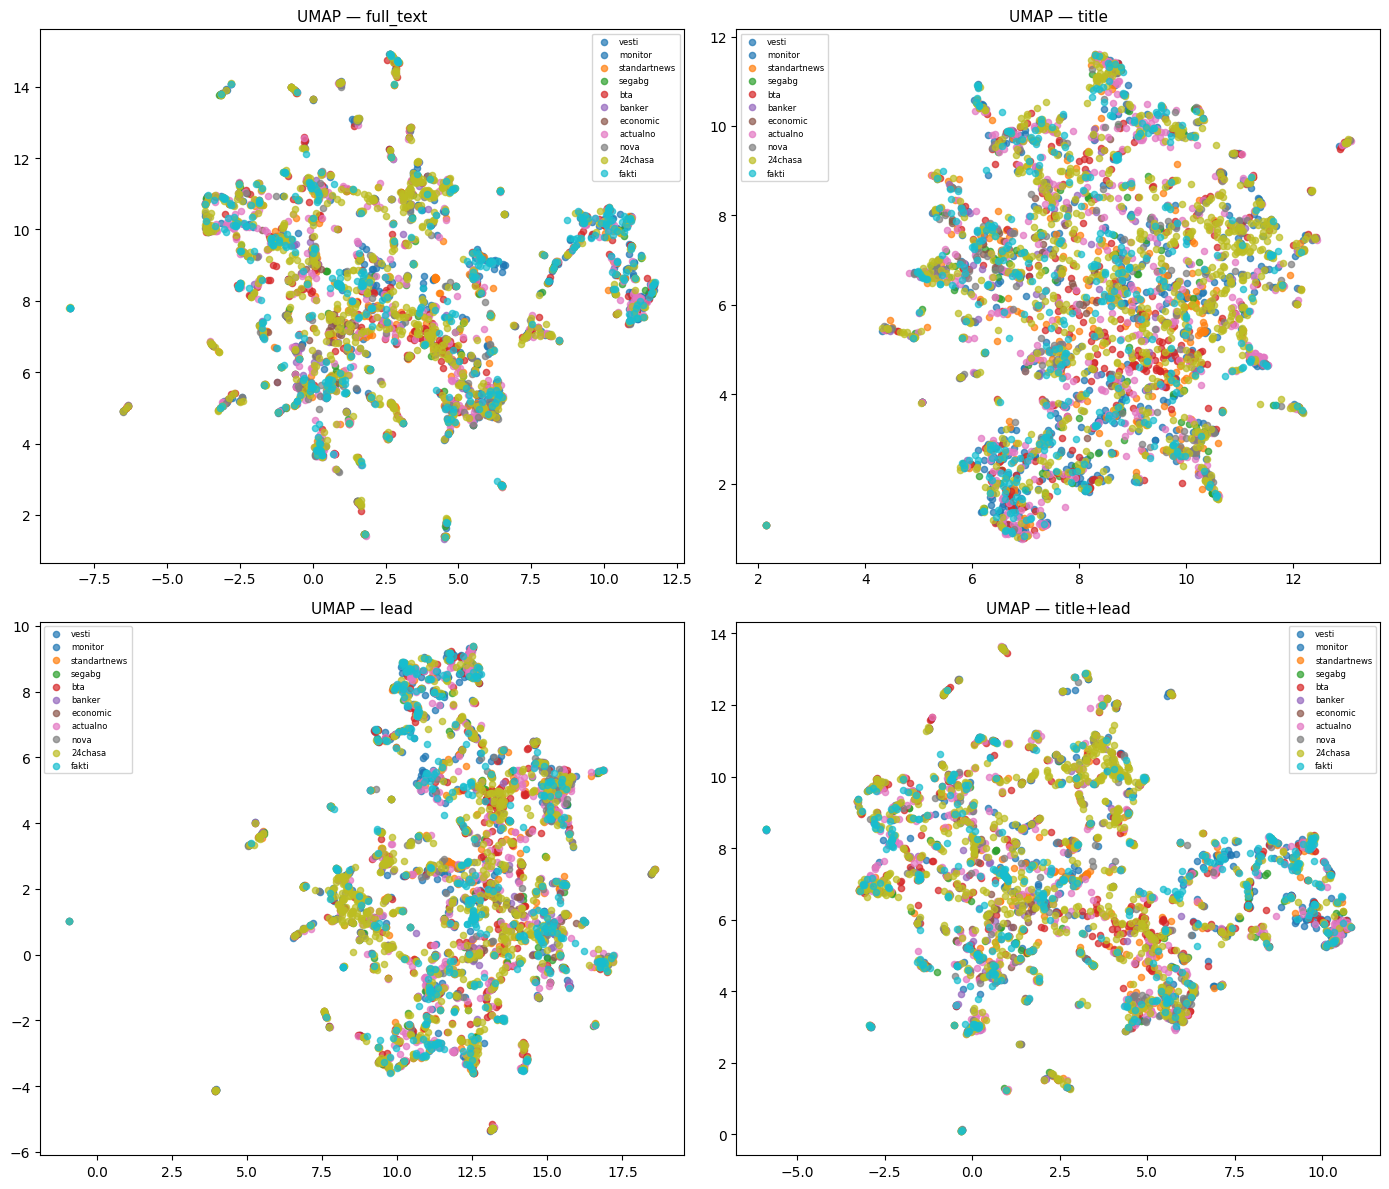

In [41]:
sources = exp_df["source"].unique()
color_map = {s: cm.tab10(i / len(sources)) for i, s in enumerate(sources)}

n_variants = len(text_embeddings)
n_cols = 2
n_rows = math.ceil(n_variants / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()

for ax, (name, emb) in zip(axes, text_embeddings.items()):
    reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
    coords = reducer.fit_transform(emb)
    for source in sources:
        mask = (exp_df["source"] == source).values
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=source, color=color_map[source], alpha=0.7, s=20)
    ax.set_title(f"UMAP — {name}", fontsize=11)
    ax.legend(loc="best", fontsize=6)

for ax in axes[n_variants:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Results — UMAP visualization

UMAP projects the high-dimensional embeddings into 2D space to visualize cluster structure.
Each point is an article, colored by source. Good embeddings for event clustering should show:
- Distinct tight groups with clear space between them (= separable events)
- Colors mixed within each group (= topic signal dominates over source style)

**`title` (top right)**
Eliminated. One large diffuse blob in the center with minimal structure. Articles are not
grouping by topic — the title alone provides too little semantic signal for BGE-M3 to
distinguish between events. Consistent with the worst gap score (0.005).

**`lead` (bottom left)**
Decent structure — some distinct clusters visible and colors well-mixed within groups.
However the main cloud remains fairly dense with no strong separation between events.

**`full_text` (top left)**
Good structure — several tight isolated clusters visible at the periphery, better separation
than lead. However slightly more compressed overall space compared to title+lead.

**`title+lead` (bottom right)**
Best structure of the four. Most distinct cluster separation — clear groups with good spacing
between them, colors well-mixed within each group, and a well-spread embedding space.
The combination of the title's concise semantic signal and the lead's factual context
produces the most interpretable event groupings.


### Decision — Text combination

**Selected: `title+lead`**

Although the similarity gap metric is identical for `lead`, `title+lead` and `full_text` (0.003),
the UMAP visualization reveals clear differences in cluster structure. `title+lead` produces
the most distinct and well-separated event clusters, making it the best choice for the
downstream clustering task.


**Note:** `full_text` produces cluster structure close to `title+lead` and achieves the same
gap score. However, given the practical constraints of the pipeline, `title+lead` is preferred.

**Resource comparison:**

| Variant | Avg words | Encoding memory | Relative speed | Storage (embeddings) |
|---|---|---|---|---|
| title | ~10 words | Low | Fast | Small |
| lead | ~40 words | Low | Fast | Small |
| title+lead | ~50 words | Low | Fast | Small |
| full_text | ~350 words | High (batch issues at >8) | Slow | Large |

- `full_text` required `batch_size=1` to avoid RuntimeError (Invalid buffer size: 64 GiB on MPS)
- `title+lead` encodes at default batch size with no memory issues
- For ~30 000 articles, the difference in encoding time and storage is significant
- Embeddings storage: `title+lead` at 1024-dim float32 ≈ 93MB for 30K articles vs
  proportionally higher processing overhead for `full_text`


## 3. Model comparison

Models tested:
1. `AIaLT-IICT/modern_bert_bg_large_uncased` — Bulgarian ModernBERT, 8192 tokens
2. `AIaLT-IICT/bert_bg_lit_web_extra_large_uncased` — Bulgarian BERT XL, web+literature domain
3. `BAAI/bge-m3` — multilingual, 8192 tokens
4. `Qwen/Qwen3-Embedding-0.6B` — multilingual, 32K tokens
5. `sentence-transformers/LaBSE` — language-agnostic BERT

In [42]:
BEST_TEXT_VARIANT = "title+lead"
texts = (exp_df["title"] + ". " + exp_df["lead"]).tolist()

print(f"Using text variant: {BEST_TEXT_VARIANT}")
print(f"Sample: {texts[0][:150]}")

Using text variant: title+lead
Sample: Терзиев: От днес "Капитолия" вече не е автокъща, връщаме Борисовата градина на софиянци. Започна принудителното премахване на чадърите към автокъщата 


In [43]:
def encode_sentence_transformer(model_id, texts):
    m = SentenceTransformer(model_id, device=DEVICE)
    if "qwen" in model_id.lower():
        return m.encode(
            texts,
            prompt_name="query",
            normalize_embeddings=True,
            show_progress_bar=True,
            batch_size=32,
        )
    return m.encode(
        texts, normalize_embeddings=True, show_progress_bar=True, batch_size=8
    )


def encode_mean_pooling(model_id, texts, batch_size=32, max_length=512):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(DEVICE)
    model.eval()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            output = model(**encoded)
        attention_mask = encoded["attention_mask"]
        token_emb = output.last_hidden_state
        mask_exp = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
        pooled = torch.sum(token_emb * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu().numpy())
        if i % (batch_size * 10) == 0:
            print(f"  {i}/{len(texts)}")
    return np.vstack(all_embeddings)

In [44]:
MODELS = {
    "ModernBERT-BG-large": ("hf", "AIaLT-IICT/modern_bert_bg_large_uncased"),
    "BERT-BG-xlarge": ("hf", "AIaLT-IICT/bert_bg_lit_web_extra_large_uncased"),
    "BGE-M3": ("st", "BAAI/bge-m3"),
    "Qwen3-0.6B": ("st", "Qwen/Qwen3-Embedding-0.6B"),
    "LaBSE": ("st", "sentence-transformers/LaBSE"),
}

In [45]:
model_embeddings = {}

for name, (enc_type, model_id) in MODELS.items():
    print(f"\n{'='*40}\nEncoding: {name}")
    if enc_type == "st":
        emb = encode_sentence_transformer(model_id, texts)
    else:
        emb = encode_mean_pooling(model_id, texts)
    model_embeddings[name] = emb
    print(f"Done — shape: {emb.shape}")


Encoding: ModernBERT-BG-large


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/467 [00:00<?, ?it/s]

Done — shape: (3735, 768)


In [46]:
model_sim_results = [similarity_stats(emb, name, exp_df) for name, emb in model_embeddings.items()]
model_sim_df = pd.DataFrame(model_sim_results).rename(columns={"variant": "model"}).sort_values("gap")
print(model_sim_df.to_string(index=False))

              model  same_source_mean  cross_source_mean   gap
ModernBERT-BG-large             0.976              0.976 0.000
     BERT-BG-xlarge             0.714              0.712 0.001
             BGE-M3             0.311              0.308 0.003
         Qwen3-0.6B             0.274              0.271 0.004
              LaBSE             0.259              0.254 0.005


### Results — Model comparison similarity statistics

**Metric:** Pairwise cosine similarity gap between same-source and cross-source article pairs.
A smaller gap indicates less source-style bias. Additionally, the overall similarity range
matters — values too close to 1.0 indicate a compressed embedding space where all articles
look similar to each other, making clustering impossible regardless of the gap.

**Observations:**

**ModernBERT-BG-large** — gap 0.000, similarity 0.976. Completely compressed embedding space.
All articles look 97.6% similar to each other regardless of topic. Mean pooling on a masked
language model collapses all embeddings to nearly the same point. The gap of 0.000 is
misleading — there is no meaningful variance in the space at all. Eliminated.

**BERT-BG-xlarge** — gap 0.001, similarity 0.714. Same problem, less extreme.
The extra large Bulgarian BERT also produces a compressed space through mean pooling.
Despite being trained on web and literature text matching our news domain, the lack of
contrastive sentence-level training prevents it from producing discriminative embeddings. Eliminated.

**BGE-M3** — gap 0.003, similarity range 0.308–0.311. Healthy embedding space with
sufficient contrast for clustering. Best gap among the sentence embedding models.

**Qwen3-0.6B** — gap 0.004, similarity range 0.271–0.274. Healthy range but slightly
more spread out than BGE-M3. Slightly higher source-style bias.

**LaBSE** — gap 0.005, similarity range 0.254–0.259. Most spread out space — highest
source-style bias among competitive models.


In [47]:
cluster_results = []

for name, emb in model_embeddings.items():
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
    labels = clusterer.fit_predict(emb)
    exp_df["cluster"] = labels

    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = round((labels == -1).sum() / len(labels), 3)

    mask = labels != -1
    sil = round(silhouette_score(emb[mask], labels[mask]), 3) if mask.sum() > 1 and n_clusters > 1 else None

    diversity = round(exp_df[exp_df["cluster"] != -1].groupby("cluster")["source"].nunique().mean(), 2)

    cluster_results.append({
        "model":      name,
        "n_clusters": n_clusters,
        "noise_ratio":noise_ratio,
        "silhouette": sil,
        "mean_sources_per_cluster": diversity,
    })

cluster_df = pd.DataFrame(cluster_results).sort_values("silhouette", ascending=False)
print(cluster_df.to_string(index=False))

              model  n_clusters  noise_ratio  silhouette  mean_sources_per_cluster
ModernBERT-BG-large           2        0.000       0.354                      7.00
              LaBSE          86        0.700       0.262                      6.29
             BGE-M3         104        0.612       0.247                      6.35
     BERT-BG-xlarge           2        0.001       0.232                      7.00
         Qwen3-0.6B           2        0.000       0.143                     10.00


### Results — HDBSCAN clustering metrics

Parameters: `min_cluster_size=5`, `metric="euclidean"`, applied identically to all models.

**n_clusters:** number of distinct event clusters found. Too few (2) indicates
a collapsed embedding space — the model cannot distinguish between events.

**noise_ratio:** proportion of articles not assigned to any cluster. Lower is better,
but some noise is expected — not every article belongs to a multi-source event.

**silhouette:** measures how well-separated clusters are (range -1 to 1, higher is better).
Note: silhouette for models with only 2 clusters (ModernBERT, BERT-BG-xlarge) is not
meaningful — a high score with 2 clusters simply reflects the 2-blob structure, not
fine-grained event separation.

**mean_sources_per_cluster:** average number of distinct sources per cluster.
Higher values indicate the model groups articles by topic rather than by source.

** **

**ModernBERT-BG-large and BERT-BG-xlarge** — 2 clusters each. Completely unusable
for event detection regardless of silhouette score. Eliminated.

**Qwen3-0.6B** — also 2 clusters despite healthy similarity range. The embedding
space is too sparse for HDBSCAN to find density peaks with these parameters.
Mean sources of 10.00 with only 2 clusters is not meaningful.

**LaBSE** — 86 clusters but 70% noise ratio. Too many articles classified as
outliers — only 30% of articles get assigned to an event cluster.

**BGE-M3** — best realistic result. 104 clusters (finest event granularity),
61% noise ratio (better than LaBSE), silhouette 0.247, and 6.35 mean sources
per cluster indicating strong cross-source event grouping.
The noise ratio of 61% will be addressed through HDBSCAN parameter tuning
in the clustering pipeline — it is not a disqualifying factor at this stage.

** here noise is expected, because we have some sources that publish special type of articles, so it's normal


/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parall

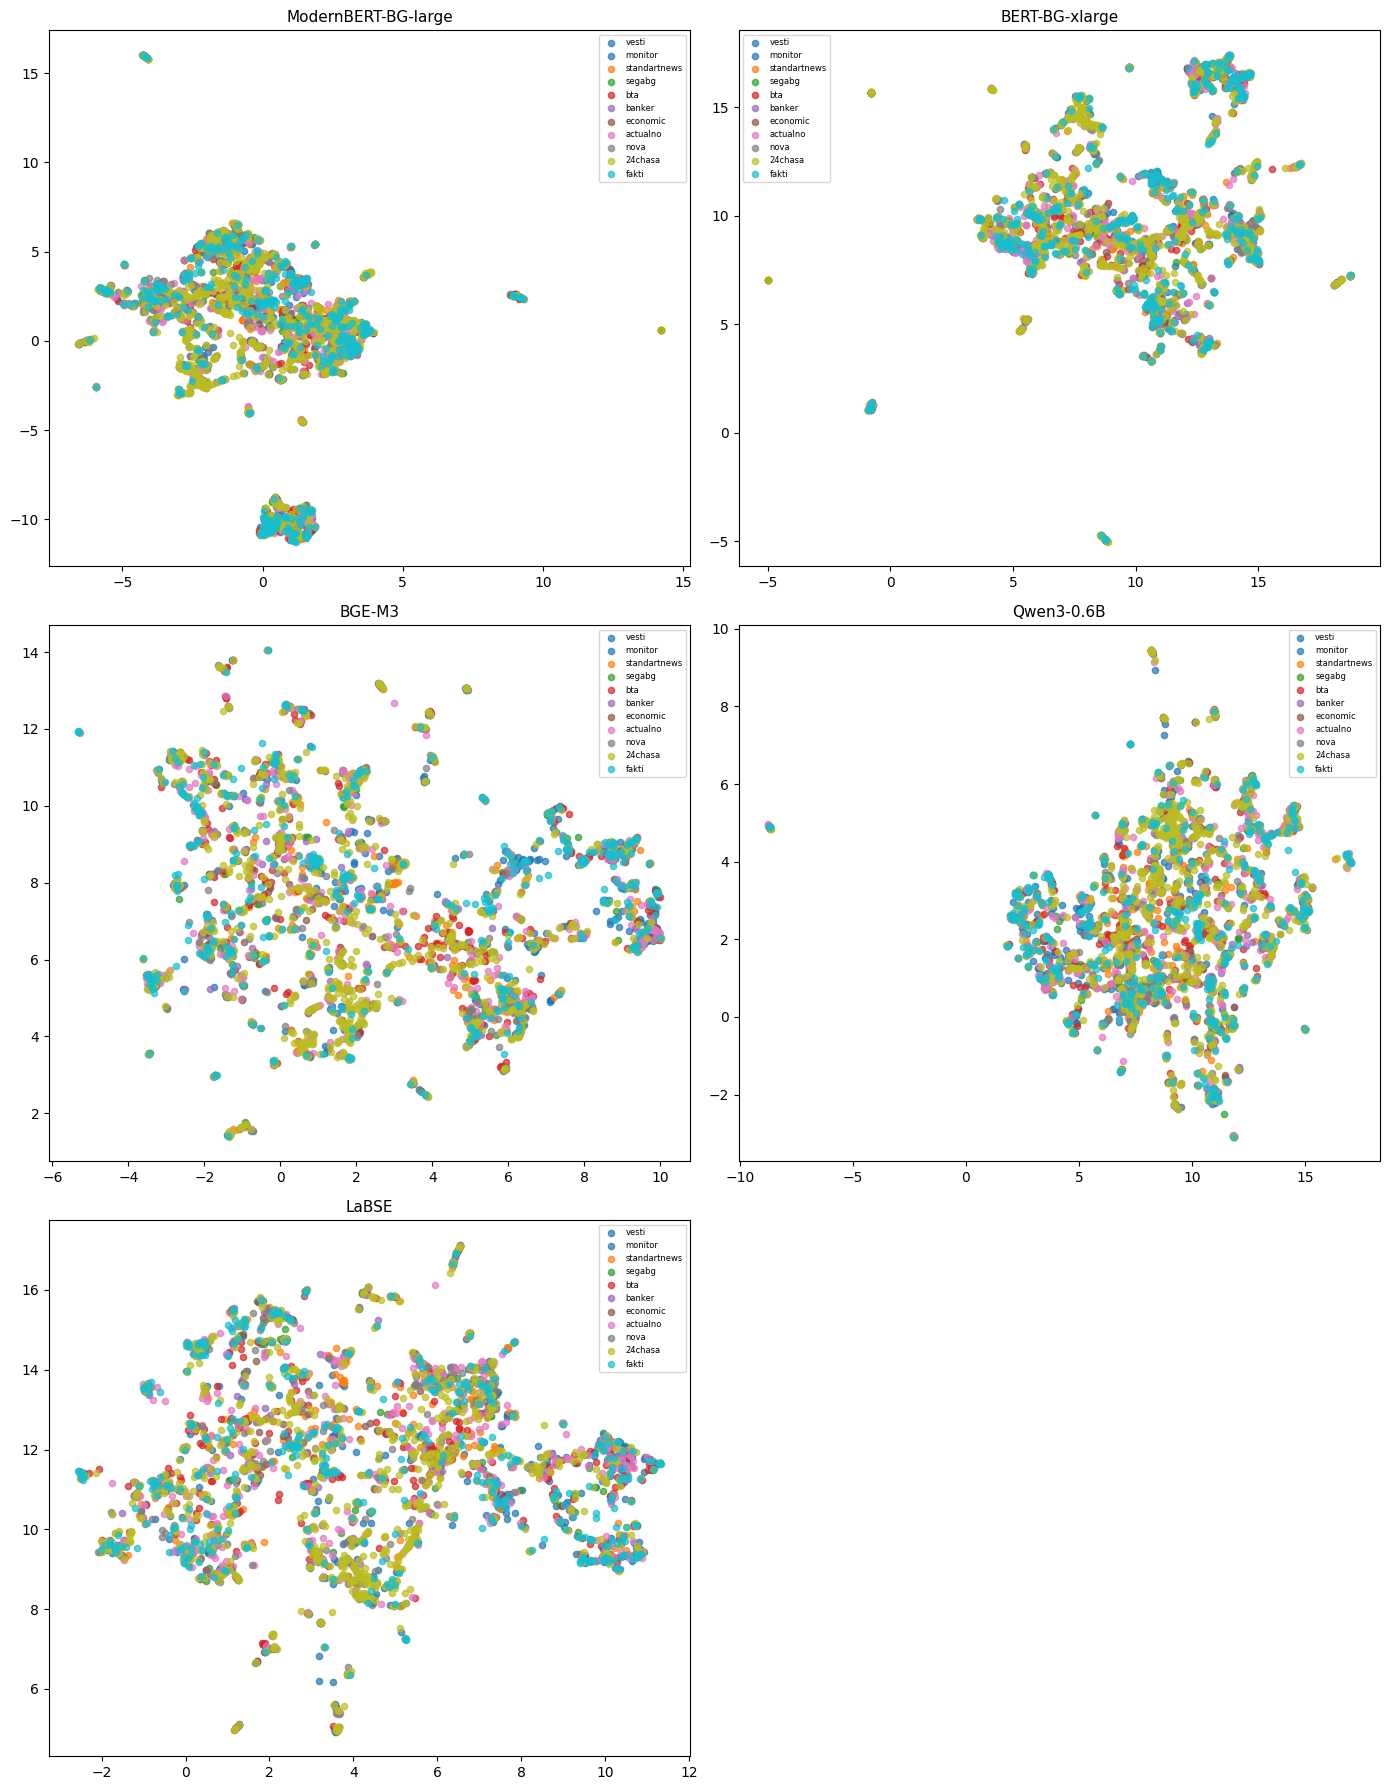

In [50]:
n_models = len(model_embeddings)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()

for ax, (name, emb) in zip(axes, model_embeddings.items()):
    reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
    coords = reducer.fit_transform(emb)
    for source in sources:
        mask = (exp_df["source"] == source).values
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=source, color=color_map[source], alpha=0.7, s=20)
    ax.set_title(name, fontsize=11)
    ax.legend(loc="best", fontsize=6)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Results — UMAP visualization

**ModernBERT-BG-large (top left)** — two large blobs matching the 2 HDBSCAN clusters.
No fine-grained event structure visible. Confirms the collapsed embedding space. Eliminated.

**BERT-BG-xlarge (top right)** — 3-4 broad regions, no tight event-level clusters.
Same compressed space problem, less extreme. Eliminated.

**Qwen3-0.6B (middle right)** — loose cloud with fuzzy sub-regions. Points are too
spread out for HDBSCAN to find density peaks — explains the 2-cluster result.

**LaBSE (bottom)** — very spread out with many isolated points scattered across the space.
Some tight groups visible but too many outliers — consistent with 70% noise ratio.

**BGE-M3 (middle left)** — best structure. Multiple distinct tight clusters with clear
separation between them, colors well-mixed within each group. Confirms it as the
strongest model for Bulgarian news event clustering.


## 4. Final summary

In [49]:
summary = model_sim_df.merge(cluster_df, on="model")
summary = summary.sort_values("silhouette", ascending=False)
summary

,model,same_source_mean,cross_source_mean,gap,n_clusters,noise_ratio,silhouette,mean_sources_per_cluster
0,ModernBERT-BG-large,0.976,0.976,0.000,2,0.000,0.354,7.00
4,LaBSE,0.259,0.254,0.005,86,0.700,0.262,6.29
2,BGE-M3,0.311,0.308,0.003,104,0.612,0.247,6.35
1,BERT-BG-xlarge,0.714,0.712,0.001,2,0.001,0.232,7.00
3,Qwen3-0.6B,0.274,0.271,0.004,2,0.000,0.143,10.00


### Decision — Embedding model

**Selected: BAAI/bge-m3**

BGE-M3 is the only model that satisfies all three requirements simultaneously:

1. **Healthy embedding space** — similarity range 0.308–0.311, not compressed like
   ModernBERT-BG-large (0.976) or BERT-BG-xlarge (0.714), and not too sparse like
   Qwen3-0.6B (0.274) which prevents HDBSCAN from finding density clusters

2. **Meaningful event clustering** — 104 distinct clusters from 3,735 articles,
   the highest of all models. LaBSE finds fewer clusters (86) with a higher noise
   ratio (70% vs 61%)

3. **Cross-source event grouping** — 6.35 mean sources per cluster confirms the model
   groups articles by topic rather than by source, which is the core requirement
   for cross-source event analysis

Additionally, the UMAP visualization confirms BGE-M3 produces the clearest event-level
structure — tight distinct clusters with good separation and colors well-mixed within
each group — while all other models show either collapsed blobs or overly sparse spaces.


## 3b. Bulgarian models retest — correct loading via SentenceTransformer

Both Bulgarian models recommend loading via SentenceTransformer framework as per their
model cards. Previous experiment used AutoModel + manual mean pooling. This section
reruns only the two Bulgarian models with the correct loading method for comparison.


In [51]:
MODELS_BG_RETEST = {
    "ModernBERT-BG-large-ST": ("st", "AIaLT-IICT/modern_bert_bg_large_uncased"),
    "BERT-BG-xlarge-ST": ("st", "AIaLT-IICT/bert_bg_lit_web_extra_large_uncased"),
}

In [52]:
bg_embeddings = {}

for name, (enc_type, model_id) in MODELS_BG_RETEST.items():
    print(f"\n{'='*40}\nEncoding: {name}")
    emb = encode_sentence_transformer(model_id, texts)
    bg_embeddings[name] = emb
    print(f"Done — shape: {emb.shape}")


Encoding: ModernBERT-BG-large-ST


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: AIaLT-IICT/modern_bert_bg_large_uncased
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/467 [00:00<?, ?it/s]

Done — shape: (3735, 1024)

Encoding: BERT-BG-xlarge-ST


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: AIaLT-IICT/bert_bg_lit_web_extra_large_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batches:   0%|          | 0/467 [00:00<?, ?it/s]

Done — shape: (3735, 1024)


In [53]:
bg_sim_results = [
    similarity_stats(emb, name, exp_df) for name, emb in bg_embeddings.items()
]
bg_sim_df = (
    pd.DataFrame(bg_sim_results).rename(columns={"variant": "model"}).sort_values("gap")
)
print(bg_sim_df.to_string(index=False))

                 model  same_source_mean  cross_source_mean   gap
ModernBERT-BG-large-ST             0.976              0.976 0.000
     BERT-BG-xlarge-ST             0.714              0.712 0.001


In [54]:
bg_cluster_results = []

for name, emb in bg_embeddings.items():
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
    labels = clusterer.fit_predict(emb)
    exp_df["cluster"] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = round((labels == -1).sum() / len(labels), 3)

    mask = labels != -1
    sil = (
        round(silhouette_score(emb[mask], labels[mask]), 3)
        if mask.sum() > 1 and n_clusters > 1
        else None
    )

    diversity = round(
        exp_df[exp_df["cluster"] != -1].groupby("cluster")["source"].nunique().mean(), 2
    )

    bg_cluster_results.append(
        {
            "model": name,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "mean_sources_per_cluster": diversity,
        }
    )

bg_cluster_df = pd.DataFrame(bg_cluster_results)
print(bg_cluster_df.to_string(index=False))

                 model  n_clusters  noise_ratio  silhouette  mean_sources_per_cluster
ModernBERT-BG-large-ST           2        0.000       0.354                       7.0
     BERT-BG-xlarge-ST           2        0.001       0.232                       7.0


/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


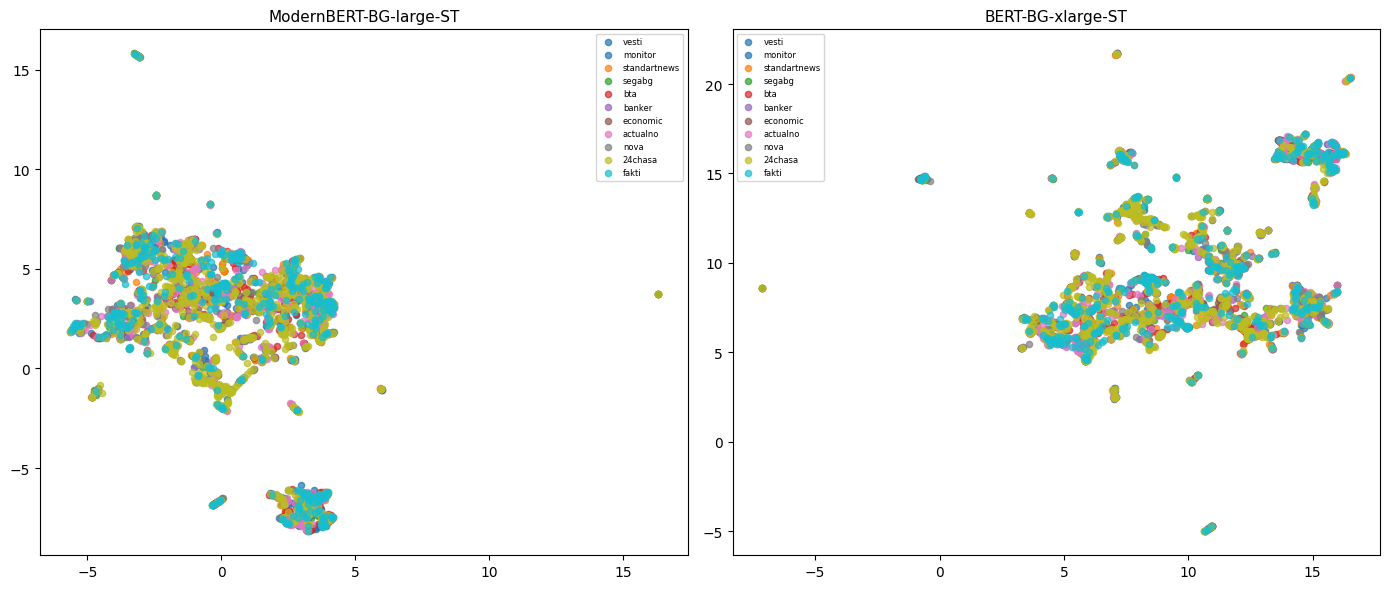

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, emb) in zip(axes, bg_embeddings.items()):
    reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
    coords = reducer.fit_transform(emb)
    for source in sources:
        mask = (exp_df["source"] == source).values
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            label=source,
            color=color_map[source],
            alpha=0.7,
            s=20,
        )
    ax.set_title(name, fontsize=11)
    ax.legend(loc="best", fontsize=6)

plt.tight_layout()
plt.show()

In [58]:
os.makedirs("../data/experiments", exist_ok=True)

for name, emb in {**model_embeddings, **bg_embeddings, **text_embeddings}.items():
    filename = name.replace("/", "_").replace(" ", "_").replace("+", "_plus_")
    np.save(f"../data/experiments/{filename}.npy", emb)
    print(f"Saved: {filename} — {emb.shape}")

Saved: ModernBERT-BG-large — (3735, 1024)
Saved: BERT-BG-xlarge — (3735, 1024)
Saved: BGE-M3 — (3735, 1024)
Saved: Qwen3-0.6B — (3735, 1024)
Saved: LaBSE — (3735, 768)
Saved: ModernBERT-BG-large-ST — (3735, 1024)
Saved: BERT-BG-xlarge-ST — (3735, 1024)
Saved: full_text — (3735, 1024)
Saved: title — (3735, 1024)
Saved: lead — (3735, 1024)
Saved: title_plus_lead — (3735, 1024)
